Import all packages need in the cell below

In [33]:
import Pkg

Pkg.add("Plots")
Pkg.add("Ipopt")
Pkg.add("GLPK")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\Saidk\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\Saidk\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\Saidk\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\Saidk\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
   Installed GLPK ───── v1.2.1
   Installed GLPK_jll ─ v5.0.1+1
  Installing 1 artifacts
   Installed artifact GLPK                  3.2 MiB
    Updating `C:\Users\Saidk\.julia\environments\v1.12\Project.toml`
  [60bf3e95] + GLPK v1.2.1
    Updating `C:\Users\Saidk\.julia\environments\v1.12\Manifest.toml`
  [60bf3e95] + GLPK v1.2.1
  [e8aa6df9] + GLPK_jll v5.0.1+1
  [781609d7] + GMP_jll v6.3.0+2
Precompiling packages...
    774.9 ms  ✓ GLPK_jll
   5520.6 ms  ✓ GLPK
  2 d

In [34]:
using Plots
using Ipopt
using GLPK

# 01 - Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

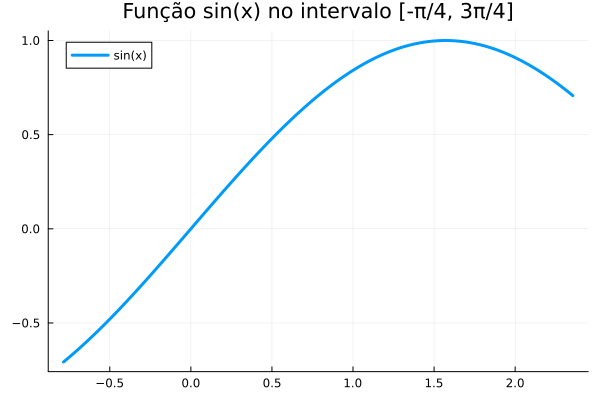

In [3]:
#code

inicio = -pi/4
fim = 3*pi/4

x = range(inicio, fim, length = 100)

y = sin.(x)

plot(x, y, label = "sin(x)", linewidth=3, title="Função sin(x) no intervalo [-π/4, 3π/4]")

# 02 - Problem Statement

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

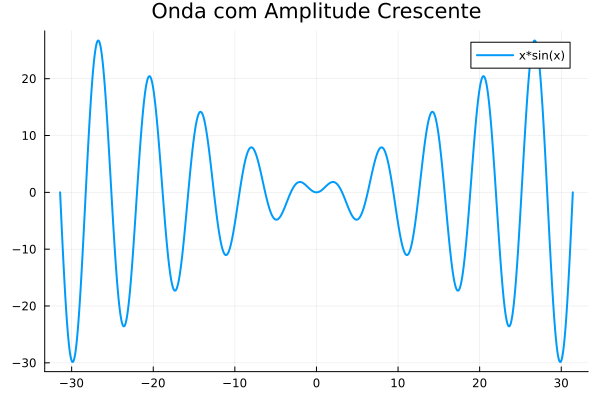

In [4]:
#code

inicio = -10*pi
fim = 10*pi

x = range(inicio, fim, length=1000)

y = x.*sin.(x)

plot(x, y, label="x*sin(x)", linewidth=2, title="Onda com Amplitude Crescente")

# 03 Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5

In [9]:
#code

using JuMP
using Ipopt

modelo_cilindro = Model(Ipopt.Optimizer)

set_silent(modelo_cilindro)

N = 10.0
c1 = 2.0
c2 = 0.5

@variable(modelo_cilindro, r >=0)
@variable(modelo_cilindro, h >=0)

set_start_value(r, 1.0)
set_start_value(h, 1.0)

@NLobjective(modelo_cilindro, Max, N * pi * r^2 * h-c1 * pi * r^2 - c2 * pi * r^2 * h * (pi * r^2 + 2 * pi * r * h))

optimize!(modelo_cilindro)

println("Raio ideal (r): ", round(value(r),digits=3)," metros")
println("Altura ideal (h): ", round(value(h),digits=3)," metros")
println("Lucro Máximo (Z): \$ ", round(objective_value(modelo_cilindro), digits=3))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Raio ideal (r): 0.826 metros
Altura ideal (h): 1.721 metros
Lucro Máximo (Z): $ 12.174


# 04 Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$

In [11]:
#code

using JuMP
using Ipopt

modelo_toldo = Model(Ipopt.Optimizer)
set_silent(modelo_toldo)

h_caixa = 2.0
w_caixa = 3.0

@variable(modelo_toldo, x >= 0, start=1.0)
@variable(modelo_toldo, y >= 0, start=1.0)

@NLobjective(modelo_toldo, Min, sqrt(x^2 + y^2))

@NLconstraint(modelo_toldo, y - (w_caixa * y / x) >= h_caixa)

optimize!(modelo_toldo)

println("Distância no chão (x): ", round(value(x), digits=3), " metros")
println("Altura na parede (y): ", round(value(y), digits=3), " metros")
println("Comprimento da lona (Z): ", round(objective_value(modelo_toldo), digits=3), " metros")


Distância no chão (x): 5.289 metros
Altura na parede (y): 4.621 metros
Comprimento da lona (Z): 7.023 metros


# 05 Problem Statement¶
Solve the Packing Problem

In [15]:
#code

using JuMP
using Ipopt

modelo_caixa = Model(Ipopt.Optimizer)
set_silent(modelo_caixa)

@variable(modelo_caixa, h >= 0, start=1.0)
@variable(modelo_caixa, w >= 0, start=1.0)
@variable(modelo_caixa, d >= 0, start=1.0)

@NLobjective(modelo_caixa, Max, h*w*d)
@NLconstraint(modelo_caixa, 2*w*h + 2*d*h + 6*w*d <= 60)

optimize!(modelo_caixa)

println("Altura ideal (h): ", round(value(h), digits=3), " cm")
println("Largura ideal (w): ", round(value(w), digits=3), " cm")
println("Profundidade ideal (d): ", round(value(d), digits=3), " cm")
println("Volume Máximo (Z): ", round(objective_value(modelo_caixa), digits=3), " cm³")


Altura ideal (h): 5.477 cm
Largura ideal (w): 1.826 cm
Profundidade ideal (d): 1.826 cm
Volume Máximo (Z): 18.257 cm³


# 06 Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

In [21]:
using JuMP
using Ipopt

modelo_opf = Model(Ipopt.Optimizer)
set_silent(modelo_opf)

yl = 9.95037190209989
al = -1.47112767430373
d3 = 0.0 

@variable(modelo_opf, 0 <= p1 <= 3, start=0)
@variable(modelo_opf, -2 <= q1 <= 2, start=0)
@variable(modelo_opf, 0 <= p2 <= 0.8, start=0)
@variable(modelo_opf, -2 <= q2 <= 2, start=0)

@variable(modelo_opf, 0.95 <= v1 <= 1.10, start=1.0)
@variable(modelo_opf, 0.95 <= v2 <= 1.10, start=1.0)
@variable(modelo_opf, 0.95 <= v3 <= 1.10, start=1.0)

@variable(modelo_opf, -pi <= d1 <= pi, start=0.0)
@variable(modelo_opf, -pi <= d2 <= pi, start=0.0)

@objective(modelo_opf, Min, 2*p1 + 1*p2)

@NLconstraint(modelo_opf, p1 == yl*cos(al)*v1^2 - yl*v1*v2*cos(d1-d2-al) + yl*cos(al)*v1^2 - yl*v1*v3*cos(d1-d3-al))
@NLconstraint(modelo_opf, p2 == yl*cos(al)*v2^2 - yl*v2*v1*cos(d2-d1-al) + yl*cos(al)*v2^2 - yl*v2*v3*cos(d2-d3-al))
@NLconstraint(modelo_opf, -0.8 == yl*cos(al)*v3^2 - yl*v3*v1*cos(d3-d1-al) + yl*cos(al)*v3^2 - yl*v3*v2*cos(d3-d2-al))

@NLconstraint(modelo_opf, q1 == -yl*sin(al)*v1^2 - yl*v1*v2*sin(d1-d2-al) - yl*sin(al)*v1^2 - yl*v1*v3*sin(d1-d3-al))
@NLconstraint(modelo_opf, q2 == -yl*sin(al)*v2^2 - yl*v2*v1*sin(d2-d1-al) - yl*sin(al)*v2^2 - yl*v2*v3*sin(d2-d3-al))
@NLconstraint(modelo_opf, -0.6 == -yl*sin(al)*v3^2 - yl*v3*v1*sin(d3-d1-al) - yl*sin(al)*v3^2 - yl*v3*v2*sin(d3-d2-al))

@NLconstraint(modelo_opf, (yl*cos(al)*v1^2 - yl*v1*v2*cos(d1-d2-al))^2 + (-yl*sin(al)*v1^2 - yl*v1*v2*sin(d1-d2-al))^2 <= 0.25^2)
@NLconstraint(modelo_opf, (yl*cos(al)*v2^2 - yl*v2*v1*cos(d2-d1-al))^2 + (-yl*sin(al)*v2^2 - yl*v2*v1*sin(d2-d1-al))^2 <= 0.25^2)

@NLconstraint(modelo_opf, (yl*cos(al)*v1^2 - yl*v1*v3*cos(d1-d3-al))^2 + (-yl*sin(al)*v1^2 - yl*v1*v3*sin(d1-d3-al))^2 <= 2.0^2)
@NLconstraint(modelo_opf, (yl*cos(al)*v3^2 - yl*v3*v1*cos(d3-d1-al))^2 + (-yl*sin(al)*v3^2 - yl*v3*v1*sin(d3-d1-al))^2 <= 2.0^2)

@NLconstraint(modelo_opf, (yl*cos(al)*v2^2 - yl*v2*v3*cos(d2-d3-al))^2 + (-yl*sin(al)*v2^2 - yl*v2*v3*sin(d2-d3-al))^2 <= 2.0^2)
@NLconstraint(modelo_opf, (yl*cos(al)*v3^2 - yl*v3*v2*cos(d3-d2-al))^2 + (-yl*sin(al)*v3^2 - yl*v3*v2*sin(d3-d2-al))^2 <= 2.0^2)

optimize!(modelo_opf)

println("P1 (Gerador 1): ", round(value(p1), digits=4))
println("P2 (Gerador 2): ", round(value(p2), digits=4))
println("Q1 (Reativo 1): ", round(value(q1), digits=4))
println("Q2 (Reativo 2): ", round(value(q2), digits=4))
println("Tensão V1: ", round(value(v1), digits=4))
println("Tensão V2: ", round(value(v2), digits=4))
println("Tensão V3: ", round(value(v3), digits=4))
println("Ângulo d1: ", round(value(d1), digits=4))
println("Ângulo d2: ", round(value(d2), digits=4))

P1 (Gerador 1): 0.0309
P2 (Gerador 2): 0.7743
Q1 (Reativo 1): 0.3209
Q2 (Reativo 2): 0.3308
Tensão V1: 1.0977
Tensão V2: 1.1
Tensão V3: 1.0664
Ângulo d1: 0.0212
Ângulo d2: 0.0419


# 07 Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [25]:
using JuMP
using Ipopt

x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y  = [2.0, 3.9, 6.1, 8.0, 9.8]

modelo_regressao = Model(Ipopt.Optimizer)
set_silent(modelo_regressao)

@variable(modelo_regressao, b0)
@variable(modelo_regressao, b1)
@variable(modelo_regressao, b2)
@variable(modelo_regressao, b3)

@objective(modelo_regressao, Min, sum( (b0 + b1*x1[i] + b2*x2[i] + b3*x3[i] - y[i])^2 for i in 1:5 ))

optimize!(modelo_regressao)

println("Beta 0: ", round(value(b0), digits=4))
println("Beta 1: ", round(value(b1), digits=4))
println("Beta 2: ", round(value(b2), digits=4))
println("Beta 3: ", round(value(b3), digits=4))
println("\nA Soma dos Erros ao Quadrado: ", round(objective_value(modelo_regressao), digits=6))

Beta 0: -0.2855
Beta 1: -0.7274
Beta 2: 4.0365
Beta 3: 0.8182

A Soma dos Erros ao Quadrado: 0.035636


# 08 Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


In [28]:
using JuMP
using Ipopt

modelo_alocacao = Model(Ipopt.Optimizer)
set_silent(modelo_alocacao)

pontuacao = [
    90  80  10  50;
    60  70  50  65;
    70  40  80  85
]

horas_necessarias = [70, 50, 85, 35]

limite_horas = 80

@variable(modelo_alocacao, x[1:3, 1:4] >= 0)

@objective(modelo_alocacao, Max, sum(pontuacao[i, j] * x[i, j] for i in 1:3, j in 1:4))

for i in 1:3
    @constraint(modelo_alocacao, sum(x[i, j] for j in 1:4) <= limite_horas)
end

for j in 1:4
    @constraint(modelo_alocacao, sum(x[i, j] for i in 1:3) == horas_necessarias[j])
end

optimize!(modelo_alocacao)

for i in 1:3
    for j in 1:4
        horas = round(value(x[i, j]), digits=1)
        
        if horas > 0
            println("Designer $i -> Projeto $j : $horas horas")
        end
    end
end
println("\n Pontuação Total de Produtividade Máxima: ", round(objective_value(modelo_alocacao), digits=1))

Designer 1 -> Projeto 1 : 70.0 horas
Designer 1 -> Projeto 2 : 10.0 horas
Designer 2 -> Projeto 2 : 40.0 horas
Designer 2 -> Projeto 3 : 5.0 horas
Designer 2 -> Projeto 4 : 35.0 horas
Designer 3 -> Projeto 3 : 80.0 horas

 Pontuação Total de Produtividade Máxima: 18825.0


# 09 Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [32]:
using JuMP
using Ipopt

modelo_dieta = Model(Ipopt.Optimizer)
set_silent(modelo_dieta)

@variable(modelo_dieta, y1 >= 0) # Maçã
@variable(modelo_dieta, y2 >= 0) # Pão
@variable(modelo_dieta, y3 >= 0) # Leite
@variable(modelo_dieta, y4 >= 0) # Ovo

@objective(modelo_dieta, Min, 1.0*y1 + 0.5*y2 + 2.0*y3 + 0.3*y4)

@constraint(modelo_dieta, calorias,  100*y1 + 200*y2 + 150*y3 +  70*y4 >= 500)
@constraint(modelo_dieta, proteina,  0.5*y1 +   4*y2 +   8*y3 +   6*y4 >= 50)
@constraint(modelo_dieta, vitaminas,   2*y1 +   0*y2 +  10*y3 +   0*y4 >= 100)

optimize!(modelo_dieta)

println("Maçãs (y1): ", round(value(y1), digits=2), " unidades")
println("Pães (y2):  ", round(value(y2), digits=2), " porções")
println("Leite (y3): ", round(value(y3), digits=2), " porções")
println("Ovos (y4):  ", round(value(y4), digits=2), " unidades")
println("Custo Mínimo Total: \$ ", round(objective_value(modelo_dieta), digits=2))

Maçãs (y1): -0.0 unidades
Pães (y2):  -0.0 porções
Leite (y3): 10.0 porções
Ovos (y4):  -0.0 unidades
Custo Mínimo Total: $ 20.0


# 10 Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [36]:
using JuMP
using GLPK

modelo_mochila = Model(GLPK.Optimizer)

@variable(modelo_mochila, x1, Bin)
@variable(modelo_mochila, x2, Bin)
@variable(modelo_mochila, x3, Bin)

@objective(modelo_mochila, Max, 120*x1 + 80*x2 + 60*x3)

@constraint(modelo_mochila, 2*x1 + 1*x2 + 1*x3 <= 3.5)

optimize!(modelo_mochila)

println("Levar Barraca?   ", value(x1) == 1.0 ? "SIM" : "NÃO")
println("Levar Fogareiro? ", value(x2) == 1.0 ? "SIM" : "NÃO")
println("Levar Comida?    ", value(x3) == 1.0 ? "SIM" : "NÃO")

peso_total = 2*value(x1) + 1*value(x2) + 1*value(x3)
println("Peso Final da Mochila: ", peso_total, " kg")
println("Valor Total (Z): \$ ", objective_value(modelo_mochila))

Levar Barraca?   SIM
Levar Fogareiro? SIM
Levar Comida?    NÃO
Peso Final da Mochila: 3.0 kg
Valor Total (Z): $ 200.0
